In [2]:
import networkx as nx
import numpy as np
import pickle
import scipy.sparse as sp
import time


# =========================
# LOAD GRAPH + MATRICES
# =========================
def load_graph_and_matrices(filepath):
    print("Loading graph...")
    with open(filepath, 'rb') as f:
        G = pickle.load(f)

    nodes = list(G.nodes())
    n = len(nodes)
    print(f"Graph loaded with {n} nodes.")

    # Baseline opinions
    s = np.array([G.nodes[node]['baseline_opinion'] for node in nodes])

    # Susceptibility
    alpha = np.array([G.nodes[node]['susceptibility'] for node in nodes])

    print("Building sparse weight matrix (W)...")
    W_raw = nx.to_scipy_sparse_array(G, nodelist=nodes, weight='weight', format='csr')

    # Row normalize
    row_sums = np.array(W_raw.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0

    D_inv = sp.diags(1.0 / row_sums)
    W = D_inv @ W_raw

    return G, nodes, W, s, alpha


# =========================
# FJ SIMULATION (ITERATIVE)
# =========================
def run_fj_simulation(W, s, alpha, max_iters=100, tolerance=1e-5):
    x = np.copy(s)

    for i in range(max_iters):
        x_new = alpha * (W @ x) + (1.0 - alpha) * s

        if np.linalg.norm(x_new - x, ord=1) < tolerance:
            break

        x = x_new

    return x


# =========================
# INFLUENCE SCORE (FAST)
# =========================
def compute_influence_scores(W, alpha, steps=20):
    """
    Power-iteration style approximation of influence
    """
    print("Computing influence scores...")
    n = W.shape[0]

    v = np.ones(n)
    scores = np.zeros(n)

    for _ in range(steps):
        v = alpha * (W @ v)
        scores += v

    return scores


# =========================
# CANDIDATE SELECTION
# =========================
def get_top_candidates(scores, top_k=1000):
    print(f"Selecting top {top_k} candidate nodes...")
    idx_sorted = np.argsort(scores)[::-1]
    return idx_sorted[:top_k]


# =========================
# GREEDY INFLUENCE MAX
# =========================
def greedy_influence_max(W, s, alpha, candidate_indices, k=10, max_iters=50):
    print("Running scalable greedy influence maximization...")

    # Baseline
    base_x = run_fj_simulation(W, s, alpha)
    base_score = np.mean(base_x)

    selected = []

    for step in range(k):
        best_gain = -np.inf
        best_node = None

        print(f"\nStep {step+1}/{k}")

        for idx in candidate_indices:
            if idx in selected:
                continue

            # Copy state
            temp_s = np.copy(s)
            temp_alpha = np.copy(alpha)

            # Apply intervention
            temp_s[idx] = 1.0
            temp_alpha[idx] = 0.0

            x_new = run_fj_simulation(W, temp_s, temp_alpha, max_iters=max_iters)
            score = np.mean(x_new)

            gain = score - base_score

            if gain > best_gain:
                best_gain = gain
                best_node = idx

        selected.append(best_node)
        base_score += best_gain

        print(f"Selected node index: {best_node} | Gain: {best_gain:.6f}")

    return selected


# =========================
# EVALUATION FUNCTION
# =========================
def evaluate_seed_set(seed_indices, W, s, alpha):
    temp_s = np.copy(s)
    temp_alpha = np.copy(alpha)

    for idx in seed_indices:
        temp_s[idx] = 1.0
        temp_alpha[idx] = 0.0

    final_x = run_fj_simulation(W, temp_s, temp_alpha)

    return np.mean(final_x), final_x


# =========================
# MAIN PIPELINE
# =========================
if __name__ == "__main__":
    G, nodes, W, s, alpha = load_graph_and_matrices('network_graph_fj_2024.pickle')

    print("\n--- BASELINE SIMULATION ---")
    start = time.time()
    x_baseline = run_fj_simulation(W, s, alpha)
    print(f"Baseline mean opinion: {np.mean(x_baseline):.4f}")
    print(f"Time: {time.time() - start:.2f}s")

    print("\n--- COMPUTING INFLUENCE SCORES ---")
    start = time.time()
    scores = compute_influence_scores(W, alpha, steps=20)
    print(f"Time: {time.time() - start:.2f}s")

    print("\n--- SELECTING CANDIDATES ---")
    candidate_indices = get_top_candidates(scores, top_k=1000)

    print("\n--- RUNNING GREEDY INFLUENCE MAX ---")
    start = time.time()
    seeds = greedy_influence_max(W, s, alpha, candidate_indices, k=10)
    print(f"Time: {time.time() - start:.2f}s")

    print("\n--- FINAL RESULTS ---")
    seed_nodes = [nodes[i] for i in seeds]
    print("Selected seed indices:", seeds)
    print("Selected seed nodes:", seed_nodes)

    print("\n--- FINAL EVALUATION ---")
    final_mean, _ = evaluate_seed_set(seeds, W, s, alpha)
    print(f"Final mean opinion after seeding: {final_mean:.4f}")

Loading graph...
Graph loaded with 48459 nodes.
Building sparse weight matrix (W)...

--- BASELINE SIMULATION ---
Baseline mean opinion: 0.3815
Time: 0.01s

--- COMPUTING INFLUENCE SCORES ---
Computing influence scores...
Time: 0.01s

--- SELECTING CANDIDATES ---
Selecting top 1000 candidate nodes...

--- RUNNING GREEDY INFLUENCE MAX ---
Running scalable greedy influence maximization...

Step 1/10
Selected node index: 267 | Gain: 0.010868

Step 2/10
Selected node index: 190 | Gain: -0.003651

Step 3/10
Selected node index: 12805 | Gain: -0.007191

Step 4/10
Selected node index: 14041 | Gain: -0.000001

Step 5/10
Selected node index: 13621 | Gain: -0.000000

Step 6/10
Selected node index: 13810 | Gain: -0.000001

Step 7/10
Selected node index: 7110 | Gain: -0.000000

Step 8/10
Selected node index: 11360 | Gain: -0.000001

Step 9/10
Selected node index: 12802 | Gain: -0.000001

Step 10/10
Selected node index: 14449 | Gain: -0.000000
Time: 96.17s

--- FINAL RESULTS ---
Selected seed indic

In [7]:
    print("\n--- SEED NODE DETAILS ---")
    for seed_idx in seeds:
        node = nodes[seed_idx]
        degree = G.degree(node)
        county = G.nodes[node]['county']
        state = G.nodes[node]['state']
        print(f"Node {seed_idx}: {county}, {state}, Degree: {degree}")

    print("\n--- FINAL EVALUATION ---")
    final_mean, x_final = evaluate_seed_set(seeds, W, s, alpha)
    baseline_mean = np.mean(x_baseline)
    print(f"Baseline mean opinion: {baseline_mean:.4f}")
    print(f"Final mean opinion after seeding: {final_mean:.4f}")
    print(f"Improvement: {final_mean - baseline_mean:.4f}")
    print(f"Fraction of counties with increased opinion: {np.mean(x_final > x_baseline):.4f}")


--- SEED NODE DETAILS ---
Node 267: Osceola County, Florida, Degree: 6637
Node 190: Travis County, Texas, Degree: 3274
Node 12805: Cass County, North Dakota, Degree: 2
Node 14041: Washington County, Tennessee, Degree: 2
Node 13621: St. Charles County, Missouri, Degree: 2
Node 13810: Lancaster County, Pennsylvania, Degree: 2
Node 7110: Jefferson County, Kentucky, Degree: 3
Node 11360: Kent County, Michigan, Degree: 2
Node 12802: Oklahoma County, Oklahoma, Degree: 2
Node 14449: Maricopa County, Arizona, Degree: 2

--- FINAL EVALUATION ---
Baseline mean opinion: 0.3815
Final mean opinion after seeding: 0.3996
Improvement: 0.0181
Fraction of counties with increased opinion: 0.9750


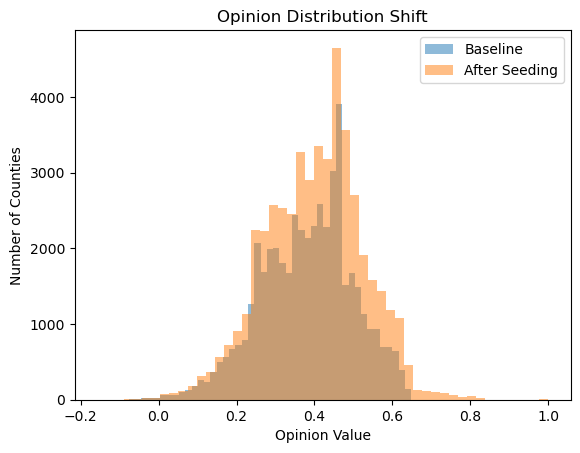

In [6]:
import matplotlib.pyplot as plt

def plot_distribution_shift(x_baseline, x_final):
    plt.figure()

    plt.hist(x_baseline, bins=50, alpha=0.5, label="Baseline")
    plt.hist(x_final, bins=50, alpha=0.5, label="After Seeding")

    plt.xlabel("Opinion Value")
    plt.ylabel("Number of Counties")
    plt.title("Opinion Distribution Shift")
    plt.legend()

    plt.show()

plot_distribution_shift(x_baseline, x_final)